In [1]:
# FER2013 - Emotion Classifier

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical


In [ ]:
data_path = "../data/fer2013.csv"
data = pd.read_csv(data_path)
data.head()


Detected emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Dataset loaded. Shape: (28709, 48, 48, 1), Labels: (28709, 7)


In [ ]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

X = []
y = []

for index, row in data.iterrows():
    pixels = np.fromstring(row['pixels'], dtype=int, sep=' ')
    img = pixels.reshape((48, 48))
    img = img.astype('float32') / 255.0  # Normalize
    X.append(img)
    y.append(row['emotion'])

X = np.array(X)
X = np.expand_dims(X, -1)  # Add channel dimension
y = to_categorical(np.array(y), num_classes=7)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')  # 7 emotions
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 64)        640       
                                                                 
 batch_normalization (Batch  (None, 46, 46, 64)        256       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 23, 23, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 128)       73856     
                                                                 
 batch_normalization_1 (Bat  (None, 21, 21, 128)       5

In [ ]:
history = model.fit(X_train, y_train, epochs=50, batch_size=64,
                    validation_data=(X_test, y_test))


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Epoch 1/50
359/359 [==============================] - 62s 171ms/step - loss: 1.9436 - accuracy: 0.2364 - val_loss: 2.1012 - val_accuracy: 0.2560 - lr: 0.0010
Epoch 2/50
359/359 [==============================] - 66s 184ms/step - loss: 1.7840 - accuracy: 0.2642 - val_loss: 2.0538 - val_accuracy: 0.2759 - lr: 0.0010
Epoch 3/50
359/359 [==============================] - 67s 186ms/step - loss: 1.7300 - accuracy: 0.2859 - val_loss: 1.7428 - val_accuracy: 0.2781 - lr: 0.0010
Epoch 4/50
359/359 [==============================] - 72s 199ms/step - loss: 1.6894 - accuracy: 0.3100 - val_loss: 1.7037 - val_accuracy: 0.3311 - lr: 0.0010
Epoch 5/50
359/359 [==============================] - 72s 200ms/step - loss: 1.6443 - accuracy: 0.3420 - val_loss: 1.5221 - val_accuracy: 0.4253 - lr: 0.0010
Epoch 6/50
359/359 [==============================] - 71s 199ms/step - loss: 1.6141 - accuracy: 0.3562 - val_loss: 1.7103 - val_accuracy: 0.3325 - lr: 0.0010
Epoch 7/50
359/359 [==============================] 

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotion_labels, yticklabels=emotion_labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Emotion Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=emotion_labels))


180/180 [==============================] - 4s 20ms/step - loss: 1.1588 - accuracy: 0.5667

✅ Test Accuracy: 56.67%


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotion_labels, yticklabels=emotion_labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Emotion Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=emotion_labels))


180/180 [==============================] - 4s 19ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.47      0.46      0.47       779
     disgust       0.00      0.00      0.00        92
        fear       0.43      0.14      0.21       838
       happy       0.78      0.85      0.82      1474
     neutral       0.46      0.65      0.54       986
         sad       0.43      0.47      0.45       977
    surprise       0.64      0.70      0.67       596

    accuracy                           0.57      5742
   macro avg       0.46      0.47      0.45      5742
weighted avg       0.55      0.57      0.54      5742



c:\Users\RITWIKA\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RITWIKA\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RITWIKA\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

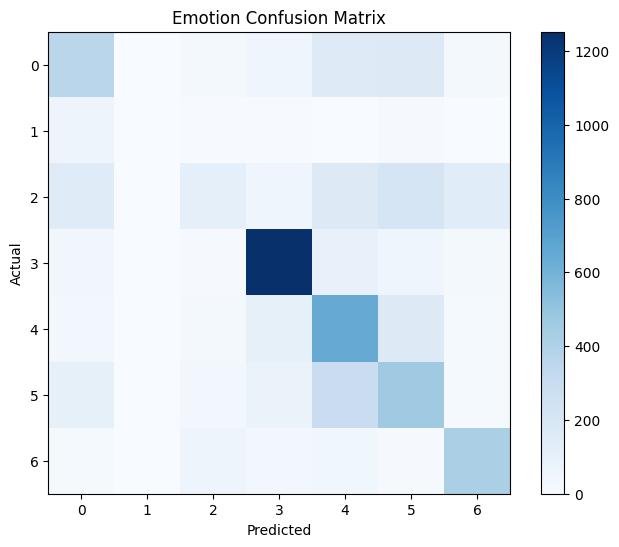

In [ ]:
model.save("../models/emotion_model.h5")
print("Model saved to ../models/emotion_model.h5")


In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



✅ Emotion model saved to ../models/emotion_model.h5


c:\Users\RITWIKA\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
